In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rsnngo/37ft-thang3737/val_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/train_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/full_dataset_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/scaler_minmax_p3.2.pkl
/kaggle/input/datasets/rsnngo/37ft-thang3737/class_weights_p3.2.json
/kaggle/input/datasets/rsnngo/37ft-thang3737/test_minmax_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/feature_columns_p3.2.json
/kaggle/input/datasets/rsnngo/37ft-thang3737/val_standard_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/test_standard_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/audit_report_p3.2.json
/kaggle/input/datasets/rsnngo/37ft-thang3737/val_minmax_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/scaler_standard_p3.2.pkl
/kaggle/input/datasets/rsnngo/37ft-thang3737/test_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/dist_label8_precap_vs_postcap_p3.2.png
/kaggle/input/datasets/rsnng

In [2]:
# !mkdir /kaggle/working/training_checkpoints
# !cp /kaggle/input/datasets/thanhkh65/dnn-student-ckpt/training_checkpoints/* /kaggle/working/training_checkpoints/


In [3]:
import os
import json
import pandas as pd

OUTPUT_DIR = "/kaggle/working/"
TRAIN_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/train_standard_p3.2.parquet"
metadata_path = f"{OUTPUT_DIR}/metadata.json"

def create_metadata_from_parquet(train_path):
    df = pd.read_parquet(train_path)
    all_columns = df.columns.tolist()
    target_col = 'label'
    if target_col not in all_columns:
        raise ValueError(f"Target column '{target_col}' not found.")
    feature_cols = [col for col in all_columns if col != target_col]
    num_features = len(feature_cols)
    unique_labels = sorted(df[target_col].astype(str).unique())
    num_classes = len(unique_labels)
    label_to_id = {label: idx for idx, label in enumerate(unique_labels)}
    id_to_label = {str(idx): label for idx, label in enumerate(unique_labels)}
    metadata = {
        "feature_cols": feature_cols,
        "target_col": target_col,
        "label_to_id": label_to_id,
        "id_to_label": id_to_label,
        "num_classes": num_classes,
        "num_features": num_features
    }
    return metadata

if not os.path.exists(metadata_path):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    metadata = create_metadata_from_parquet(TRAIN_PATH)
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=4)
    print(f"Metadata saved to {metadata_path}")
else:
    print("Metadata already exists.")

Metadata saved to /kaggle/working//metadata.json


In [4]:
# import tensorflow as tf
# from tensorflow.keras import layers, Model
# import torch
# import numpy as np
# import pandas as pd
# from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score
# import os

# # =============================================================================
# # CẤU HÌNH
# # =============================================================================
# NUM_FEATURES = 37
# EMBEDDIM = 256
# NUM_CLASSES = 8

# # Đường dẫn file .pth (có thể là teacher_kd.pth hoặc ssl-cl-dnn-optuna-10-6.pth)
# PTH_PATH = "/kaggle/input/models/truongdanghuy/ssl-cl-dnn/pytorch/default/3/teacher_ssl_dnn.pth"   # thay đổi nếu cần
# OUTPUT_KERAS_PATH = "/kaggle/working/ssl_cl_dnn_teacher.keras"

# # =============================================================================
# # XÂY DỰNG KIẾN TRÚC MODEL
# # =============================================================================
# def build_encoder():
#     inputs = tf.keras.Input(shape=(NUM_FEATURES,))
#     x = layers.Dense(512, activation='relu')(inputs)
#     x = layers.Dense(512, activation='relu')(x)
#     x = layers.Dense(256, activation='relu')(x)
#     x = layers.Dense(EMBEDDIM, activation='relu')(x)
#     return Model(inputs, x, name='encoder')

# def build_classifier():
#     inputs = tf.keras.Input(shape=(EMBEDDIM,))
#     x = layers.Dense(256, activation='relu')(inputs)
#     x = layers.Dense(NUM_CLASSES, activation='linear')(x)   # logits
#     return Model(inputs, x, name='classifier')

# def build_full_teacher():
#     encoder = build_encoder()
#     classifier = build_classifier()
#     inputs = encoder.input
#     embeddings = encoder.output
#     outputs = classifier(embeddings)
#     model = Model(inputs, outputs, name='ssl_cl_dnn')
#     return model, encoder, classifier

# # =============================================================================
# # HÀM LOAD TRỌNG SỐ TỪ PYTORCH (.pth) SANG KERAS
# # =============================================================================
# def load_pytorch_weights_to_keras(pth_path, keras_encoder, keras_classifier):
#     """Load weights from PyTorch state_dict into Keras encoder and classifier."""
#     state = torch.load(pth_path, map_location='cpu')
    
#     # Lấy state_dict của encoder và classifier (có thể nằm trong 'encoder_state_dict', 'classifier_state_dict'
#     # hoặc trực tiếp trong state['model'] tùy file)
#     if 'encoder_state_dict' in state and 'classifier_state_dict' in state:
#         enc_sd = state['encoder_state_dict']
#         cls_sd = state['classifier_state_dict']
#     elif 'model' in state:
#         # Trường hợp file teacher_kd.pth chỉ có một state_dict
#         enc_sd = {k.replace('encoder.', ''): v for k, v in state['model'].items() if k.startswith('encoder.')}
#         cls_sd = {k.replace('classifier.', ''): v for k, v in state['model'].items() if k.startswith('classifier.')}
#     else:
#         raise ValueError("File .pth không có cấu trúc encoder_state_dict/classifier_state_dict hoặc model")
    
#     def extract_weights(sd):
#         """Trích xuất weight và bias theo thứ tự layer."""
#         items = []
#         for key, tensor in sd.items():
#             # Tìm số thứ tự layer (dạng '0', '1', ...) trong key
#             parts = key.split('.')
#             layer_idx = None
#             for p in parts:
#                 if p.isdigit():
#                     layer_idx = int(p)
#                     break
#             if layer_idx is None:
#                 continue
#             if 'weight' in key:
#                 items.append((layer_idx, 'weight', tensor))
#             elif 'bias' in key:
#                 items.append((layer_idx, 'bias', tensor))
#         items.sort(key=lambda x: x[0])
#         weights = [t for (_, typ, t) in items if typ == 'weight']
#         biases  = [t for (_, typ, t) in items if typ == 'bias']
#         return weights, biases
    
#     # Lấy danh sách Dense layer (bỏ qua InputLayer)
#     enc_dense = [layer for layer in keras_encoder.layers if isinstance(layer, layers.Dense)]
#     cls_dense = [layer for layer in keras_classifier.layers if isinstance(layer, layers.Dense)]
    
#     # Load encoder
#     enc_w, enc_b = extract_weights(enc_sd)
#     for i, layer in enumerate(enc_dense):
#         if i < len(enc_w):
#             w = enc_w[i].numpy().T   # PyTorch (out, in) -> Keras (in, out)
#             b = enc_b[i].numpy()
#             layer.set_weights([w, b])
#             print(f"[Encoder] Loaded layer {i}: {layer.name} shape {w.shape}")
#         else:
#             print(f"[Encoder] Warning: missing weight for layer {i}")
    
#     # Load classifier
#     cls_w, cls_b = extract_weights(cls_sd)
#     for i, layer in enumerate(cls_dense):
#         if i < len(cls_w):
#             w = cls_w[i].numpy().T
#             b = cls_b[i].numpy()
#             layer.set_weights([w, b])
#             print(f"[Classifier] Loaded layer {i}: {layer.name} shape {w.shape}")
#         else:
#             print(f"[Classifier] Warning: missing weight for layer {i}")
    
#     print("✅ Weight loading completed.")

# # =============================================================================
# # XÂY DỰNG MODEL VÀ LOAD TRỌNG SỐ
# # =============================================================================
# print("Building teacher model...")
# teacher_model, encoder, classifier = build_full_teacher()
# teacher_model.summary()

# print(f"\nLoading weights from: {PTH_PATH}")
# load_pytorch_weights_to_keras(PTH_PATH, encoder, classifier)

# # =============================================================================
# # LƯU MODEL THÀNH FILE .KERAS
# # =============================================================================
# teacher_model.save(OUTPUT_KERAS_PATH)
# print(f"\n✅ Teacher model saved to: {OUTPUT_KERAS_PATH}")
# print(f"File size: {os.path.getsize(OUTPUT_KERAS_PATH) / (1024*1024):.2f} MB")

In [5]:
# import os
# import json
# import numpy as np
# import pandas as pd
# import tensorflow as tf
# from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
# import matplotlib.pyplot as plt
# import seaborn as sns

# # ============================
# # CẤU HÌNH ĐƯỜNG DẪN
# # ============================
# MODEL_PATH = "/kaggle/working/ssl_cl_dnn_teacher.keras"        # file .keras đã chuyển đổi
# METADATA_PATH = "/kaggle/working/metadata.json"                # metadata (tạo từ train)
# TEST_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/test_standard_p3.2.parquet"  # file test của bạn

# # ============================
# # 1. LOAD METADATA
# # ============================
# with open(METADATA_PATH, 'r') as f:
#     metadata = json.load(f)

# feature_cols = metadata["feature_cols"]
# target_col = metadata["target_col"]
# num_features = metadata["num_features"]
# num_classes = metadata["num_classes"]
# id_to_label = metadata["id_to_label"]   # dict: "0"->"class_name", ...

# print(f"📊 Số features: {num_features}, Số classes: {num_classes}")

# # ============================
# # 2. LOAD MODEL
# # ============================
# model = tf.keras.models.load_model(MODEL_PATH)
# print("✅ Model loaded.")

# # ============================
# # 3. LOAD DỮ LIỆU TEST
# # ============================
# df_test = pd.read_parquet(TEST_PATH)

# # Kiểm tra các cột có đúng không
# missing_cols = set(feature_cols) - set(df_test.columns)
# if missing_cols:
#     raise ValueError(f"Missing columns in test: {missing_cols}")

# X_test = df_test[feature_cols].values.astype(np.float32)
# y_raw = df_test[target_col].values

# # Chuyển nhãn về dạng số nguyên theo metadata (nếu nhãn là string)
# # Giả sử label_to_id có trong metadata
# label_to_id = metadata["label_to_id"]
# if isinstance(y_raw[0], str):
#     y_true = np.array([label_to_id[label] for label in y_raw])
# else:
#     y_true = y_raw.astype(int)

# print(f"🧪 Test samples: {X_test.shape[0]}")

# # ============================
# # 4. DỰ ĐOÁN
# # ============================
# logits = model.predict(X_test, verbose=0)
# probs = tf.nn.softmax(logits, axis=-1).numpy()
# y_pred = np.argmax(probs, axis=1)

# # ============================
# # 5. BÁO CÁO PHÂN LOẠI (4 chữ số thập phân)
# # ============================
# print("\n" + "="*50)
# print("CLASSIFICATION REPORT")
# print("="*50)
# report = classification_report(y_true, y_pred, digits=4, target_names=[id_to_label[str(i)] for i in range(num_classes)])
# print(report)

# # Accuracy & Macro F1
# acc = accuracy_score(y_true, y_pred)
# f1_macro = f1_score(y_true, y_pred, average='macro')
# print(f"\n✅ Accuracy      : {acc:.4f}")
# print(f"✅ Macro F1-score: {f1_macro:.4f}")

# # ============================
# # 6. CONFUSION MATRIX
# # ============================
# cm = confusion_matrix(y_true, y_pred)
# plt.figure(figsize=(10, 8))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=[id_to_label[str(i)] for i in range(num_classes)],
#             yticklabels=[id_to_label[str(i)] for i in range(num_classes)])
# plt.xlabel('Predicted')
# plt.ylabel('True')
# plt.title('Confusion Matrix')
# plt.tight_layout()
# plt.show()

# # (Tuỳ chọn) Lưu ảnh
# # plt.savefig("/kaggle/working/confusion_matrix.png")

In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 1: Imports & Config
# ──────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import time
import xgboost as xgb

# Hyperparameters
BATCH_SIZE = 128
LEARNING_RATE = 0.005
EPOCHS = 50
TEMPERATURE = 2.0
ALPHA = 0.1

# Paths (adjust to your environment)
OUTPUT_DIR = "/kaggle/working/"
METADATA_PATH = f"{OUTPUT_DIR}/metadata.json"
TRAIN_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/train_standard_p3.2.parquet"
VAL_PATH   = "/kaggle/input/datasets/rsnngo/37ft-thang3737/val_standard_p3.2.parquet"
TEST_PATH  = "/kaggle/input/datasets/rsnngo/37ft-thang3737/test_standard_p3.2.parquet"
XGB_MODEL_PATH = "/kaggle/input/models/lamthicucb2203709/cw-cnn/keras/default/1/xgboost_best_model.json"
CNN_MODEL_PATH = "/kaggle/input/models/lamthicucb2203709/cw-cnn/keras/default/1/best_model_cnn1d_128_128_256.keras"

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 2: Load Data
# ──────────────────────────────────────────────────────────────────────────────
with open(METADATA_PATH, 'r') as f:
    metadata = json.load(f)

feature_cols = metadata['feature_cols']
target_col = metadata['target_col']
num_classes = metadata['num_classes']
num_features = metadata['num_features']

df_train = pd.read_parquet(TRAIN_PATH)
df_val   = pd.read_parquet(VAL_PATH)
df_test  = pd.read_parquet(TEST_PATH)

X_train = df_train[feature_cols].values.astype(np.float32)
y_train = df_train[target_col].values.astype(np.int32)
X_val   = df_val[feature_cols].values.astype(np.float32)
y_val   = df_val[target_col].values.astype(np.int32)
X_test  = df_test[feature_cols].values.astype(np.float32)
y_test  = df_test[target_col].values.astype(np.int32)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Number of classes: {num_classes}")
# Tính class weights dựa trên y_train (đã undersampled)
from sklearn.utils.class_weight import compute_class_weight

unique_classes = np.unique(y_train)
class_weights_raw = compute_class_weight('balanced', classes=unique_classes, y=y_train)
# Giới hạn weight tối đa = 3.0
MAX_WEIGHT = 3.0
class_weights = np.minimum(class_weights_raw, MAX_WEIGHT)

print("Class counts:", np.bincount(y_train))
print("Class weights (capped at 3.0):", class_weights)

# Chuyển thành tensor để dùng trong loss
class_weights_tensor = tf.constant(class_weights, dtype=tf.float32)

Train: (4468344, 37), Val: (1117087, 37), Test: (1396358, 37)
Number of classes: 8
Class counts: [ 670231 1916729  619802    8013  278953  383443   15173  576000]
Class weights (capped at 3.0): [0.83335895 0.29140426 0.9011636  3.         2.00228354 1.45665197
 3.         0.96969271]


I0000 00:00:1786351285.981057      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786351285.984253      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 3: Load Teacher Models
# ──────────────────────────────────────────────────────────────────────────────
# XGBoost (outputs probabilities)
xgb_model = xgb.XGBClassifier()
xgb_model.load_model(XGB_MODEL_PATH)

# CNN (outputs logits)
cnn_model = tf.keras.models.load_model(CNN_MODEL_PATH)

In [9]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 4: Build Student Model (MLP 64-32, outputs logits)
# ──────────────────────────────────────────────────────────────────────────────
def build_student(input_dim, num_classes):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='linear')   # logits
    ])
    return model

student = build_student(num_features, num_classes)
student.summary()
print(f"Student parameters: {student.count_params()}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,776 (18.66 KB)

 Trainable params: 4,776 (18.66 KB)

 Non-trainable params: 0 (0.00 B)

Student parameters: 4776


In [10]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 5: Precompute XGBoost probabilities & Create tf.data.Datasets
# ──────────────────────────────────────────────────────────────────────────────
print("Precomputing XGBoost probabilities...")
xgb_probs_train = xgb_model.predict_proba(X_train).astype(np.float32)
xgb_probs_val   = xgb_model.predict_proba(X_val).astype(np.float32)
xgb_probs_test  = xgb_model.predict_proba(X_test).astype(np.float32)

print(f"Train shape: {xgb_probs_train.shape}, Val shape: {xgb_probs_val.shape}")

# Tạo dataset kèm theo probs đã precompute
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train, xgb_probs_train)) \
                              .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset   = tf.data.Dataset.from_tensor_slices((X_val, y_val, xgb_probs_val)) \
                              .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset  = tf.data.Dataset.from_tensor_slices((X_test, y_test, xgb_probs_test)) \
                              .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Precomputing XGBoost probabilities...
Train shape: (4468344, 8), Val shape: (1117087, 8)


In [11]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 6: Loss Function and Training Step (with class weights)
# ──────────────────────────────────────────────────────────────────────────────
ce_loss = losses.SparseCategoricalCrossentropy(from_logits=True)

@tf.function
def distillation_loss(student_logits, fused_teacher_probs, true_labels, alpha, temperature, class_weights):
    # Hard loss with class weights
    hard_loss_per_sample = tf.nn.sparse_softmax_cross_entropy_with_logits(
        labels=true_labels, logits=student_logits
    )
    weights = tf.gather(class_weights, true_labels)
    hard_loss = tf.reduce_mean(hard_loss_per_sample * weights)
    
    # KD loss
    student_probs = tf.nn.softmax(student_logits / temperature)
    kd_loss = tf.reduce_mean(
        tf.reduce_sum(fused_teacher_probs * tf.math.log(fused_teacher_probs / (student_probs + 1e-8)), axis=1)
    ) * (temperature ** 2)
    
    return (1 - alpha) * hard_loss + alpha * kd_loss

def train_step(x_batch, y_batch, xgb_probs_batch):
    # CNN teacher: logits -> softmax with temperature
    cnn_logits = cnn_model(x_batch, training=False)
    cnn_probs = tf.nn.softmax(cnn_logits / TEMPERATURE)
    
    # XGBoost: precomputed probabilities -> temperature scaling
    xgb_probs_tf = tf.constant(xgb_probs_batch, dtype=tf.float32)
    xgb_probs_scaled = xgb_probs_tf ** (1.0 / TEMPERATURE)
    xgb_probs_scaled = xgb_probs_scaled / tf.reduce_sum(xgb_probs_scaled, axis=1, keepdims=True)
    
    teacher_probs = [cnn_probs, xgb_probs_scaled]
    
    # Compute confidence weights per batch (batch‑wise mean of max prob)
    conf_scores = []
    for probs in teacher_probs:
        max_probs = tf.reduce_max(probs, axis=1)
        conf = tf.reduce_mean(max_probs)
        conf_scores.append(conf)
    conf_scores = tf.stack(conf_scores)
    weights = conf_scores / tf.reduce_sum(conf_scores)
    
    # Fuse teacher predictions (same weights for whole batch)
    fused = weights[0] * teacher_probs[0] + weights[1] * teacher_probs[1]
    
    # Student forward and loss
    with tf.GradientTape() as tape:
        student_logits = student(x_batch, training=True)
        loss = distillation_loss(student_logits, fused, y_batch, ALPHA, TEMPERATURE, class_weights_tensor)
    grads = tape.gradient(loss, student.trainable_variables)
    optimizer.apply_gradients(zip(grads, student.trainable_variables))
    return loss

In [12]:
import pickle
import glob
import json
import tensorflow as tf

CHECKPOINT_DIR = f"{OUTPUT_DIR}/training_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# File lưu metadata
METADATA_FILE = f"{CHECKPOINT_DIR}/metadata.pkl"

def save_metadata(epoch, best_val_loss, wait_lr, current_lr,
                  train_losses, val_losses, train_accuracies, val_accuracies, best_weights):
    metadata = {
        'epoch': epoch,
        'best_val_loss': best_val_loss,
        'wait_lr': wait_lr,
        'current_lr': current_lr,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'best_weights': best_weights
    }
    with open(METADATA_FILE, 'wb') as f:
        pickle.dump(metadata, f)

def load_metadata():
    if not os.path.exists(METADATA_FILE):
        return None, 0
    with open(METADATA_FILE, 'rb') as f:
        metadata = pickle.load(f)
    return metadata, metadata['epoch']

In [13]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 7: Training Loop với cải tiến (bỏ ES, checkpoint resume với optimizer state)
# ──────────────────────────────────────────────────────────────────────────────
from tqdm.auto import tqdm
import tensorflow as tf

GRAD_CLIP_NORM = 1.0

# Khởi tạo optimizer (Adam)
optimizer = optimizers.Adam(learning_rate=LEARNING_RATE)

# Tạo checkpoint object (lưu model + optimizer)
checkpoint = tf.train.Checkpoint(model=student, optimizer=optimizer)
checkpoint_manager = tf.train.CheckpointManager(
    checkpoint, 
    directory=CHECKPOINT_DIR,
    max_to_keep=2
)

# Load metadata và checkpoint nếu có
metadata, start_epoch = load_metadata()
if metadata is not None:
    print(f"Resuming from epoch {start_epoch}")
    best_val_loss = metadata['best_val_loss']
    wait_lr = metadata['wait_lr']
    current_lr = metadata['current_lr']
    train_losses = metadata['train_losses']
    val_losses = metadata['val_losses']
    train_accuracies = metadata['train_accuracies']
    val_accuracies = metadata['val_accuracies']
    best_weights = metadata['best_weights']
    # Khôi phục optimizer và model weights từ checkpoint
    latest_checkpoint = tf.train.latest_checkpoint(CHECKPOINT_DIR)
    if latest_checkpoint is not None:
        checkpoint.restore(latest_checkpoint).expect_partial()
        print(f"  ✅ Restored model and optimizer from {latest_checkpoint}")
    else:
        print("  ⚠️  No checkpoint file found, but metadata exists. Starting fresh.")
    epoch_start = start_epoch + 1
else:
    print("Starting fresh training")
    best_val_loss = float('inf')
    best_weights = None
    wait_lr = 0
    current_lr = LEARNING_RATE
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    epoch_start = 1

# Các tham số ReduceLROnPlateau
patience_lr = 5
lr_factor = 0.5
min_lr = 1e-4

# Hàm train_step với gradient clipping
@tf.function
def train_step(x_batch, y_batch, xgb_probs_batch):
    # Teacher CNN
    cnn_logits = cnn_model(x_batch, training=False)
    cnn_probs = tf.nn.softmax(cnn_logits / TEMPERATURE)
    
    # Teacher XGBoost
    xgb_probs_scaled = xgb_probs_batch ** (1.0 / TEMPERATURE)
    xgb_probs_scaled = xgb_probs_scaled / tf.reduce_sum(xgb_probs_scaled, axis=1, keepdims=True)
    
    teacher_probs = [cnn_probs, xgb_probs_scaled]
    
    # Confidence weights
    conf_scores = [tf.reduce_mean(tf.reduce_max(probs, axis=1)) for probs in teacher_probs]
    conf_scores = tf.stack(conf_scores)
    weights = conf_scores / tf.reduce_sum(conf_scores)
    fused = weights[0] * teacher_probs[0] + weights[1] * teacher_probs[1]
    
    with tf.GradientTape() as tape:
        student_logits = student(x_batch, training=True)
        # Hard loss với class weights
        hard_loss_per_sample = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=y_batch, logits=student_logits
        )
        sample_weights = tf.gather(class_weights_tensor, y_batch)
        hard_loss = tf.reduce_mean(hard_loss_per_sample * sample_weights)
        # KD loss
        student_probs = tf.nn.softmax(student_logits / TEMPERATURE)
        kd_loss = tf.reduce_mean(
            tf.reduce_sum(fused * tf.math.log(fused / (student_probs + 1e-8)), axis=1)
        ) * (TEMPERATURE ** 2)
        loss = (1 - ALPHA) * hard_loss + ALPHA * kd_loss
    
    grads = tape.gradient(loss, student.trainable_variables)
    # Gradient clipping
    grads, _ = tf.clip_by_global_norm(grads, GRAD_CLIP_NORM)
    optimizer.apply_gradients(zip(grads, student.trainable_variables))
    return loss

# Vòng lặp training
for epoch in range(epoch_start, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS} (LR = {current_lr:.6f})")
    epoch_loss = 0.0
    num_batches = 0
    
    # Training
    pbar = tqdm(train_dataset, desc="Training", unit="batch")
    for x_batch, y_batch, xgb_probs_batch in pbar:
        loss = train_step(x_batch, y_batch, xgb_probs_batch)
        epoch_loss += loss.numpy()
        num_batches += 1
        pbar.set_postfix({"loss": f"{loss.numpy():.4f}"})
    
    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)
    
    # Train accuracy
    train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
    for x_batch, y_batch, _ in train_dataset:
        student_logits = student(x_batch, training=False)
        train_acc_metric.update_state(y_batch, student_logits)
    train_acc = train_acc_metric.result().numpy()
    train_accuracies.append(train_acc)
    
    # Validation
    val_loss_epoch = 0.0
    val_num_batches = 0
    val_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
    
    for x_batch, y_batch, xgb_probs_batch in val_dataset:
        cnn_logits = cnn_model(x_batch, training=False)
        cnn_probs = tf.nn.softmax(cnn_logits / TEMPERATURE)
        xgb_probs_scaled = xgb_probs_batch ** (1.0 / TEMPERATURE)
        xgb_probs_scaled = xgb_probs_scaled / tf.reduce_sum(xgb_probs_scaled, axis=1, keepdims=True)
        teacher_probs = [cnn_probs, xgb_probs_scaled]
        
        conf_scores = [tf.reduce_mean(tf.reduce_max(probs, axis=1)) for probs in teacher_probs]
        conf_scores = tf.stack(conf_scores)
        weights = conf_scores / tf.reduce_sum(conf_scores)
        fused = weights[0] * teacher_probs[0] + weights[1] * teacher_probs[1]
        
        student_logits = student(x_batch, training=False)
        hard_loss_per_sample = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=y_batch, logits=student_logits
        )
        sample_weights = tf.gather(class_weights_tensor, y_batch)
        hard_loss = tf.reduce_mean(hard_loss_per_sample * sample_weights)
        student_probs = tf.nn.softmax(student_logits / TEMPERATURE)
        kd_loss = tf.reduce_mean(
            tf.reduce_sum(fused * tf.math.log(fused / (student_probs + 1e-8)), axis=1)
        ) * (TEMPERATURE ** 2)
        loss_val = (1 - ALPHA) * hard_loss + ALPHA * kd_loss
        
        val_loss_epoch += loss_val.numpy()
        val_num_batches += 1
        val_acc_metric.update_state(y_batch, student_logits)
    
    avg_val_loss = val_loss_epoch / val_num_batches
    val_losses.append(avg_val_loss)
    val_acc = val_acc_metric.result().numpy()
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    
    # Lưu checkpoint (model + optimizer)
    checkpoint_manager.save()
    print(f"  💾 Checkpoint saved at epoch {epoch}")
    
    # Lưu metadata
    save_metadata(epoch, best_val_loss, wait_lr, current_lr,
                  train_losses, val_losses, train_accuracies, val_accuracies, best_weights)
    
    # ModelCheckpoint (best by val_loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_weights = student.get_weights()
        student.save("/kaggle/working/student_best.keras")
        print(f"  ✅ New best model saved with val_loss = {avg_val_loss:.6f}")
        wait_lr = 0
    else:
        wait_lr += 1
    
    # ReduceLROnPlateau
    if wait_lr >= patience_lr and current_lr > min_lr:
        current_lr = max(current_lr * lr_factor, min_lr)
        # Cập nhật learning rate cho optimizer
        if hasattr(optimizer.learning_rate, 'assign'):
            optimizer.learning_rate.assign(current_lr)
        else:
            optimizer.learning_rate = current_lr
        wait_lr = 0
        print(f"  🔻 Learning rate reduced to {current_lr:.6f}")

# Restore best weights
if best_weights is not None:
    student.set_weights(best_weights)
    print(f"\nRestored best model with val_loss = {best_val_loss:.6f}")

# Xóa checkpoint
import shutil
shutil.rmtree(CHECKPOINT_DIR, ignore_errors=True)
print("Checkpoints cleaned up.")
print("Training completed!")

Starting fresh training

Epoch 1/50 (LR = 0.005000)


Training:   0%|          | 0/34909 [00:00<?, ?batch/s]

Epoch 1 | Train Loss: 0.3832 | Val Loss: 0.3537 | Train Acc: 0.7888 | Val Acc: 0.7885
  💾 Checkpoint saved at epoch 1
  ✅ New best model saved with val_loss = 0.353700

Epoch 2/50 (LR = 0.005000)


Training:   0%|          | 0/34909 [00:00<?, ?batch/s]

Epoch 2 | Train Loss: 0.3456 | Val Loss: 0.3414 | Train Acc: 0.7931 | Val Acc: 0.7927
  💾 Checkpoint saved at epoch 2
  ✅ New best model saved with val_loss = 0.341355

Epoch 3/50 (LR = 0.005000)


...

Epoch 48 | Train Loss: 0.2975 | Val Loss: 0.2971 | Train Acc: 0.8198 | Val Acc: 0.8191
  💾 Checkpoint saved at epoch 48
  ✅ New best model saved with val_loss = 0.297137

Epoch 49/50 (LR = 0.001250)


Training:   0%|          | 0/34909 [00:00<?, ?batch/s]

Epoch 49 | Train Loss: 0.2976 | Val Loss: 0.2970 | Train Acc: 0.8188 | Val Acc: 0.8183
  💾 Checkpoint saved at epoch 49
  ✅ New best model saved with val_loss = 0.297020

Epoch 50/50 (LR = 0.001250)


Training:   0%|          | 0/34909 [00:00<?, ?batch/s]

Epoch 50 | Train Loss: 0.2975 | Val Loss: 0.2972 | Train Acc: 0.8182 | Val Acc: 0.8176
  💾 Checkpoint saved at epoch 50

Restored best model with val_loss = 0.297020
Checkpoints cleaned up.
Training completed!


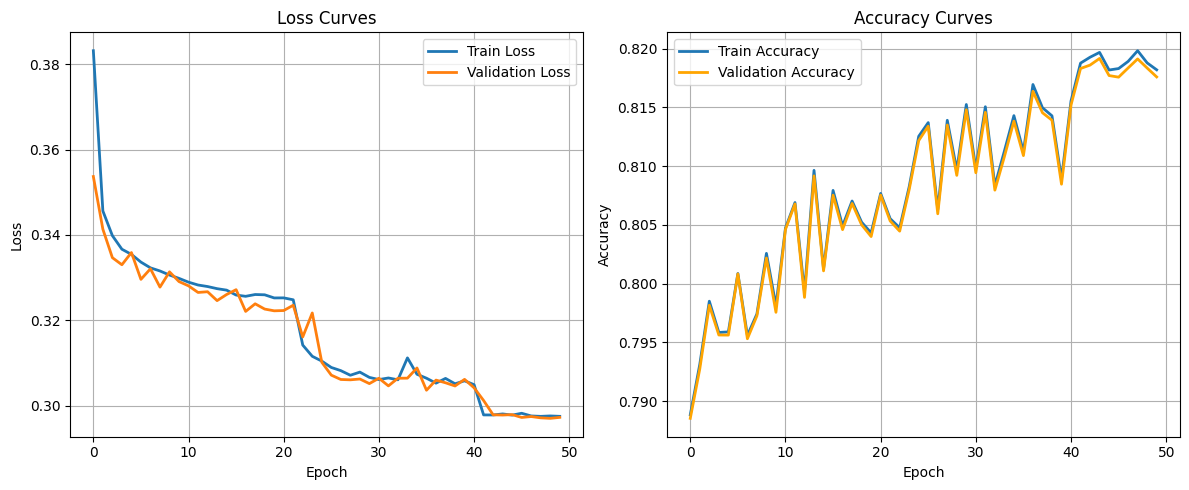

In [14]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 8: Plot Training Curves (đủ train/val loss và train/val accuracy)
# ──────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(12,5))

# Subplot 1: Loss curves
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(True)

# Subplot 2: Accuracy curves
plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Accuracy', linewidth=2)
plt.plot(val_accuracies, label='Validation Accuracy', linewidth=2, color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150)
plt.show()

   98/10910 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step

I0000 00:00:1786384871.033037      77 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


10910/10910 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step
===== Classification Report =====
              precision    recall  f1-score   support

           0       0.84      0.83      0.84    209448
           1       0.96      0.75      0.84    598978
           2       0.54      0.89      0.67    193688
           3       0.77      0.24      0.37      2504
           4       0.86      0.86      0.86     87173
           5       0.71      0.78      0.74    119826
           6       0.61      0.13      0.21      4741
           7       1.00      1.00      1.00    180000

    accuracy                           0.82   1396358
   macro avg       0.79      0.68      0.69   1396358
weighted avg       0.86      0.82      0.83   1396358



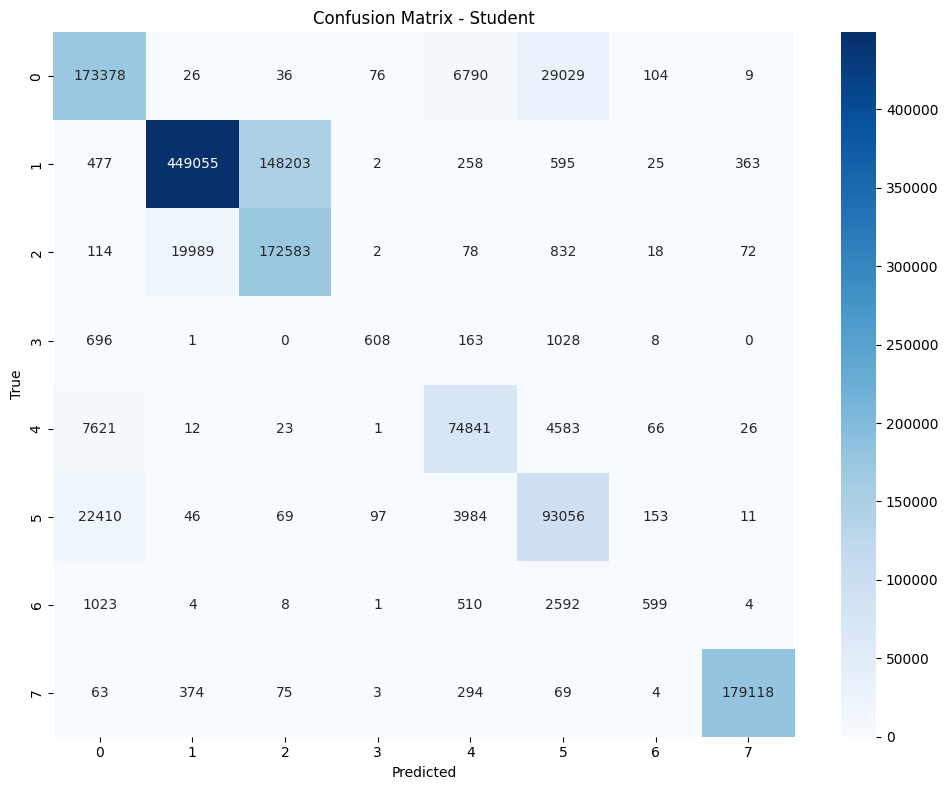

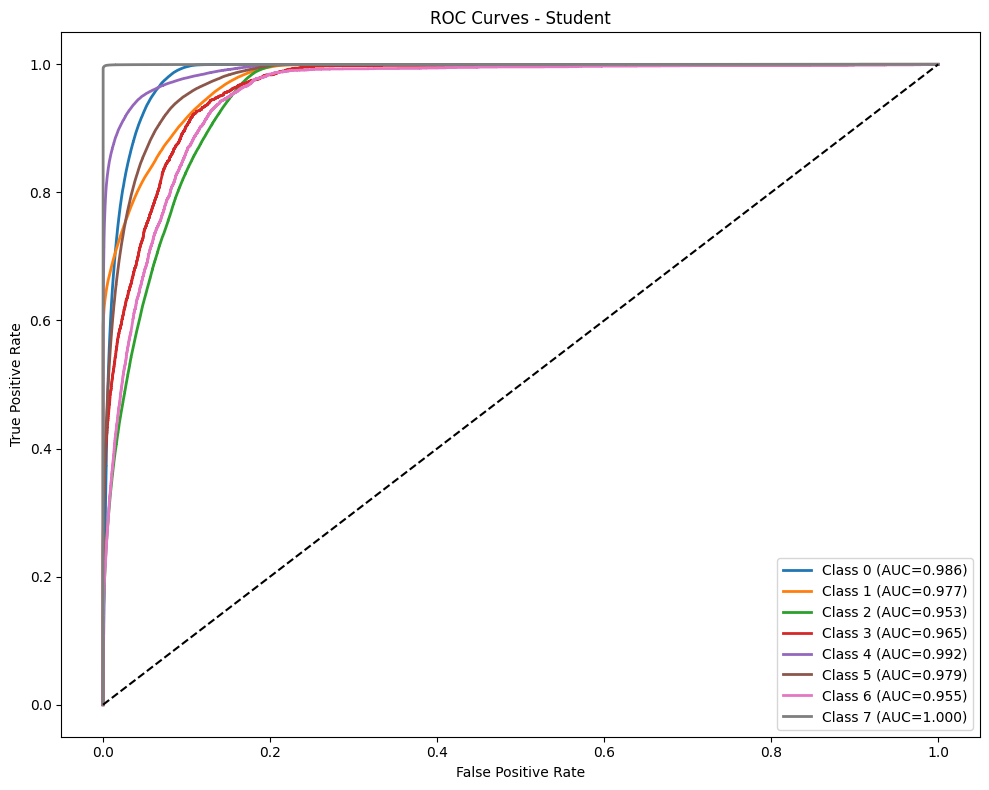

In [15]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 9: Evaluation on Test Set
# ──────────────────────────────────────────────────────────────────────────────
test_logits = student.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_preds = np.argmax(test_logits, axis=1)
test_probs = tf.nn.softmax(test_logits).numpy()

print("===== Classification Report =====")
print(classification_report(y_test, test_preds, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix - Student')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150)
plt.show()

# ROC Curves
y_bin = label_binarize(y_test, classes=range(num_classes))
plt.figure(figsize=(10,8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], test_probs[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC={auc(fpr, tpr):.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Student')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curves.png", dpi=150)
plt.show()

In [16]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 10: Heaviness Metrics (sửa lỗi FLOPs)
# ──────────────────────────────────────────────────────────────────────────────
# Model size
student.save("temp_student.keras")
size_mb = os.path.getsize("temp_student.keras") / (1024*1024)
os.remove("temp_student.keras")
print(f"Model size: {size_mb:.4f} MB")
print(f"Total parameters: {student.count_params()}")

# Approximate FLOPs (sửa lỗi)
def approx_flops(model):
    total = 0
    for layer in model.layers:
        if len(layer.weights) > 0:  # Dense layers có weights
            kernel = layer.weights[0]  # shape (input_dim, output_dim)
            input_dim = kernel.shape[0]
            output_dim = kernel.shape[1]
            total += input_dim * output_dim + output_dim  # phép nhân + bias
    return total

print(f"FLOPs per sample (approx): {approx_flops(student)}")

# Inference time
N = 2000
start = time.perf_counter()
student.predict(X_test[:N], batch_size=BATCH_SIZE, verbose=0)
inf_time = (time.perf_counter() - start) / N * 1000  # ms per sample
print(f"Inference time per sample: {inf_time:.4f} ms")

Model size: 0.0358 MB
Total parameters: 4776
FLOPs per sample (approx): 4776
Inference time per sample: 0.1717 ms


In [17]:
# # ──────────────────────────────────────────────────────────────────────────────
# # CELL: Evaluation (có thể chạy độc lập hoặc sau khi train)
# # ──────────────────────────────────────────────────────────────────────────────

# import os
# import json
# import numpy as np
# import pandas as pd
# import tensorflow as tf
# from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
# from sklearn.preprocessing import label_binarize
# import matplotlib.pyplot as plt
# import seaborn as sns

# # ----- Cấu hình -----
# # Đường dẫn đến model đã train (dùng khi chạy độc lập)
# MODEL_PATH = "/kaggle/input/models/truongdanghuy/mlp-student/keras/default/1/MLP2x32.keras"      # File model tốt nhất từ training
# METADATA_PATH = "/kaggle/working/metadata.json"
# TEST_PATH = "/kaggle/input/datasets/rsnngo/standard-4m6-ciciot2023/test_standard.parquet"
# BATCH_SIZE = 128
# OUTPUT_DIR = "/kaggle/working/"   # Thư mục output để lưu ảnh

# # ----- 1. Load metadata -----
# with open(METADATA_PATH, 'r') as f:
#     metadata = json.load(f)
# num_classes = metadata['num_classes']
# feature_cols = metadata['feature_cols']
# target_col = metadata['target_col']

# # ----- 2. Load model (nếu chưa có sẵn) -----
# try:
#     # Nếu biến 'student' đã tồn tại (từ training), dùng nó
#     student
# except NameError:
#     print("Loading model from file...")
#     student = tf.keras.models.load_model(MODEL_PATH)
#     print("Model loaded.")

# # ----- 3. Load dữ liệu test -----
# df_test = pd.read_parquet(TEST_PATH)
# X_test = df_test[feature_cols].values.astype(np.float32)
# y_test = df_test[target_col].values.astype(np.int32)

# # ----- 4. Dự đoán -----
# test_logits = student.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
# test_preds = np.argmax(test_logits, axis=1)
# test_probs = tf.nn.softmax(test_logits).numpy()

# # ----- 5. Classification Report với 4 số thập phân -----
# print("\n" + "="*60)
# print("CLASSIFICATION REPORT (digits=4)")
# print("="*60)
# print(classification_report(y_test, test_preds, digits=4, zero_division=0))

# # ----- 6. AUC (macro, weighted, micro) -----
# y_bin = label_binarize(y_test, classes=range(num_classes))
# auc_macro = roc_auc_score(y_bin, test_probs, average='macro', multi_class='ovr')
# auc_weighted = roc_auc_score(y_bin, test_probs, average='weighted', multi_class='ovr')
# auc_micro = roc_auc_score(y_bin, test_probs, average='micro', multi_class='ovr')
# print("\n" + "-"*40)
# print(f"Macro AUC   : {auc_macro:.4f}")
# print(f"Weighted AUC: {auc_weighted:.4f}")
# print(f"Micro AUC   : {auc_micro:.4f}")
# print("-"*40)

# # ----- 7. Confusion Matrix với count và % theo hàng -----
# cm = confusion_matrix(y_test, test_preds)
# # Tính phần trăm theo hàng (mỗi hàng = nhãn thực tế)
# cm_percent = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

# plt.figure(figsize=(10, 8))
# sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=True)

# # Thêm annotation thủ công (count + percentage)
# for i in range(cm.shape[0]):
#     for j in range(cm.shape[1]):
#         count = cm[i, j]
#         pct = cm_percent[i, j]
#         # Chọn màu chữ tương phản
#         color = 'white' if count > cm.max() * 0.4 else 'black'
#         plt.text(j + 0.5, i + 0.5, f"{count}\n({pct:.1f}%)",
#                  ha='center', va='center', color=color, fontsize=10)

# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.title('Confusion Matrix (counts and row percentages)')
# plt.tight_layout()
# plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_with_pct.png", dpi=150)
# plt.show()

# # ----- 8. ROC curves (tùy chọn) -----
# plt.figure(figsize=(10, 8))
# for i in range(num_classes):
#     fpr, tpr, _ = roc_curve(y_bin[:, i], test_probs[:, i])
#     plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC={roc_auc_score(y_bin[:, i], test_probs[:, i]):.3f})')
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curves - Student')
# plt.legend(loc='lower right')
# plt.tight_layout()
# plt.savefig(f"{OUTPUT_DIR}/roc_curves.png", dpi=150)
# plt.show()